# AI-Assisted Extraction of Architectural Parameters from RISC-V ISA Specifications

**Task:** given short snippets from the RISC-V Privileged Specification, extract every
architectural parameter the text marks as implementation-specific / optional /
configurable (signal words: *may, might, should, optional, optionally,
implementation-defined, implementation-specific*).

**Approach:** two LLMs — one open-source (Mistral 7B Instruct via OpenRouter, free tier) and one closed-source (Google Gemini) — are run on the same snippets through
the same prompt-iteration process (V1 → V4) and scored with Precision / Recall / F1 /
Hallucination count / Schema compliance against a hand-written ground truth.

## Part A — Setup

In [ ]:
# ==========================================
# Install Required Libraries
# ==========================================

!pip -q install \
openai \
huggingface_hub \
pandas \
matplotlib \
pyyaml \
scikit-learn


In [ ]:
# ==========================================
# Import Libraries
# ==========================================

import os
import json
import yaml
import time

import pandas as pd
import matplotlib.pyplot as plt

from huggingface_hub import login

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:


from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get("HF_TOKEN")

login(token=HF_TOKEN)

print("Login successful!")

Login successful!


In [ ]:
folders = [
    "dataset",
    "prompts",
    "outputs",
    "evaluation",
    "graphs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created!")

Project folders created!


## Part B — Model Selection & Dataset

In [ ]:
# NOTE: OpenRouter's specific ":free" model IDs rotate frequently (providers
# add/remove free tiers with little notice). Using "openrouter/free" — their
# own auto-router — picks a currently-available free model automatically, so
# this cell doesn't 404 when a specific model gets delisted.
MODEL_NAME = "openrouter/free"

print("Model Selected:")
print(MODEL_NAME)


Model Selected:
openrouter/free


In [ ]:
# ==========================================
# Create OpenRouter Client (Mistral, free tier — no HF credits needed)
# ==========================================
# Get a free API key at https://openrouter.ai/keys and store it in Colab's
# Secrets panel (key icon on the left sidebar) as OPENROUTER_API_KEY.

from openai import OpenAI
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

print("OpenRouter client ready (Mistral-7B-Instruct, free tier)!")


OpenRouter client ready (Mistral-7B-Instruct, free tier)!


In [ ]:
dataset = [
    {
        "id": 1,
        "source": "Privileged Spec 19.3.1",
        "text": """
Caches organize copies of data into cache blocks, each of which represents a contiguous, naturally aligned power-of-two (or NAPOT) range of memory locations. A cache block is identified by any of the physical addresses corresponding to the underlying memory locations. The capacity and organization of a cache and the size of a cache block are both implementation-specific, and the execution environment provides software a means to discover information about the caches and cache blocks in a system. In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system.

"""
    },

    {
        "id": 2,
        "source": "Privileged Spec 2.1",
        "text": """
Conventional" R/W accessibility of CSRs according to address mapping
The standard RISC-V ISA sets aside a 12-bit encoding space (csr[11:0]) for up to 4,096 CSRs. By convention, the upper 4 bits of the CSR address (csr[11:8]) are used to encode the read and write accessibility of the CSRs according to privilege level as shown in Table 1. The top two bits (csr[11:10]) indicate whether the register is read/write (00,01, or 10) or read-only (11). The next two bits (csr[9:8]) encode the lowest privilege level that can access the CSR

"""
    }
]

print(f"Loaded {len(dataset)} snippets.")

Loaded 2 snippets.


In [ ]:
# ==========================================
# Create OpenRouter Client (Mistral, free tier — no HF credits needed)
# ==========================================
# Get a free API key at https://openrouter.ai/keys and store it in Colab's
# Secrets panel (key icon on the left sidebar) as OPENROUTER_API_KEY.

from openai import OpenAI
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

print("OpenRouter client ready (Mistral-7B-Instruct, free tier)!")


OpenRouter client ready (Mistral-7B-Instruct, free tier)!


In [ ]:

dataset = [
    {
        "id": 1,
        "source": "Privileged Spec 19.3.1",
        "text": """
Caches organize copies of data into cache blocks, each of which represents a contiguous, naturally aligned power-of-two (or NAPOT) range of memory locations. A cache block is identified by any of the physical addresses corresponding to the underlying memory locations. The capacity and organization of a cache and the size of a cache block are both implementation-specific, and the execution environment provides software a means to discover information about the caches and cache blocks in a system. In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system.

"""
    },

    {
        "id": 2,
        "source": "Privileged Spec 2.1",
        "text": """
Conventional" R/W accessibility of CSRs according to address mapping
The standard RISC-V ISA sets aside a 12-bit encoding space (csr[11:0]) for up to 4,096 CSRs. By convention, the upper 4 bits of the CSR address (csr[11:8]) are used to encode the read and write accessibility of the CSRs according to privilege level as shown in Table 1. The top two bits (csr[11:10]) indicate whether the register is read/write (00,01, or 10) or read-only (11). The next two bits (csr[9:8]) encode the lowest privilege level that can access the CSR

"""
    }
]

print(f"Loaded {len(dataset)} snippets.")

Loaded 2 snippets.


In [ ]:
import pandas as pd

df = pd.DataFrame(dataset)

df

,id,source,text
0,1,Privileged Spec 19.3.1,\nCaches organize copies of data into cache bl...
1,2,Privileged Spec 2.1,"\nConventional"" R/W accessibility of CSRs acco..."


## Part C — Prompt Engineering, First Pass (Mistral, Snippet 1 only)

This first pass tries prompt V1 by itself to see the raw failure mode before building
a systematic prompt-comparison loop below.

In [ ]:
PROMPT_V1 = """
You are an expert in the RISC-V ISA.

Extract architectural parameters.

Return YAML.
"""

In [ ]:
example = dataset[0]["text"]

full_prompt = PROMPT_V1 + "\n\n" + example

print(full_prompt)


You are an expert in the RISC-V ISA.

Extract architectural parameters.

Return YAML.



Caches organize copies of data into cache blocks, each of which represents a contiguous, naturally aligned power-of-two (or NAPOT) range of memory locations. A cache block is identified by any of the physical addresses corresponding to the underlying memory locations. The capacity and organization of a cache and the size of a cache block are both implementation-specific, and the execution environment provides software a means to discover information about the caches and cache blocks in a system. In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system.




In [ ]:
response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "user",
            "content": full_prompt
        }
    ],
    max_tokens=1000,
    temperature=0
)

In [ ]:
answer = response.choices[0].message.content

print(answer)

```yaml
cache:
  block:
    size: implementation-specific
    alignment: naturally aligned
    range: contiguous power-of-two or NAPOT
    identification: any physical address in the underlying memory locations
  capacity: implementation-specific
  organization: implementation-specific
  discovery_mechanism: provided by execution environment
  cmo_extensions:
    block_size_uniformity: uniform throughout the system
```


In [ ]:
with open("outputs/mistral_v1_output.txt", "w") as file:
    file.write(answer)

print("Output saved successfully!")

Output saved successfully!


In [ ]:
import re
import yaml

def parse_yaml_response(response_text):
    """
    Extract YAML from an LLM response and parse it.
    """

    # Find the YAML block between ```yaml and ```
    match = re.search(r"```yaml(.*?)```", response_text, re.DOTALL)

    if match:
        yaml_text = match.group(1).strip()
    else:
        yaml_text = response_text.strip()

    print("===== Extracted YAML =====")
    print(yaml_text)
    print("==========================")

    return yaml.safe_load(yaml_text)

In [ ]:
yaml_data = parse_yaml_response(answer)
print(yaml_data)

===== Extracted YAML =====
cache:
  block:
    size: implementation-specific
    alignment: naturally aligned
    range: contiguous power-of-two or NAPOT
    identification: any physical address in the underlying memory locations
  capacity: implementation-specific
  organization: implementation-specific
  discovery_mechanism: provided by execution environment
  cmo_extensions:
    block_size_uniformity: uniform throughout the system
{'cache': {'block': {'size': 'implementation-specific', 'alignment': 'naturally aligned', 'range': 'contiguous power-of-two or NAPOT', 'identification': 'any physical address in the underlying memory locations'}, 'capacity': 'implementation-specific', 'organization': 'implementation-specific', 'discovery_mechanism': 'provided by execution environment', 'cmo_extensions': {'block_size_uniformity': 'uniform throughout the system'}}}


In [ ]:
prompts = {

"V1": """
You are an expert in the RISC-V ISA.

Extract architectural parameters.

Return ONLY valid YAML.
""",

"V2": """
You are an expert in the RISC-V ISA.

Extract ONLY implementation-defined or configurable architectural parameters.

Indicators include:

- implementation-specific
- implementation-defined
- implementation-dependent
- optional
- optionally
- may
- might
- should

Ignore:

- definitions
- mandatory properties
- architectural background
- derived information

Return ONLY valid YAML.
""",

"V3": """
You are a RISC-V ISA architect.

Task:

Extract ONLY configurable architectural parameters.

Each parameter MUST be explicitly supported by the specification.

If there is no supporting text,
DO NOT extract it.

Return ONLY valid YAML.

Schema:

architectural_parameters:

  - name:
    description:
    type:
    constraints:
    evidence:
"""
}

In [ ]:
for name in prompts:
    print(name)

V1
V2
V3


In [ ]:
selected_prompt = prompts["V1"]

In [ ]:
full_prompt = f"""
{selected_prompt}

Specification:

{dataset[0]["text"]}
"""

print(full_prompt)



You are an expert in the RISC-V ISA.

Extract architectural parameters.

Return ONLY valid YAML.


Specification:


Caches organize copies of data into cache blocks, each of which represents a contiguous, naturally aligned power-of-two (or NAPOT) range of memory locations. A cache block is identified by any of the physical addresses corresponding to the underlying memory locations. The capacity and organization of a cache and the size of a cache block are both implementation-specific, and the execution environment provides software a means to discover information about the caches and cache blocks in a system. In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system.





In [ ]:
response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "user",
            "content": full_prompt
        }
    ],
    max_tokens=1000,
    temperature=0
)

answer = response.choices[0].message.content
print(answer)



```yaml
cache_block_size:
  - description: Uniform power-of-two (or NAPOT) size across the system
  - type: implementation-specific

cache_capacity:
  - description: Total data storage capacity of the cache
  - type: implementation-specific

cache_organization:
  - description: Structure and arrangement of cache lines (e.g., direct-mapped, set-associative)
  - type: implementation-specific
```



In [ ]:
yaml_data = parse_yaml_response(answer)

print(yaml_data)

===== Extracted YAML =====
cache_block_size:
  - description: Uniform power-of-two (or NAPOT) size across the system
  - type: implementation-specific

cache_capacity:
  - description: Total data storage capacity of the cache
  - type: implementation-specific

cache_organization:
  - description: Structure and arrangement of cache lines (e.g., direct-mapped, set-associative)
  - type: implementation-specific
{'cache_block_size': [{'description': 'Uniform power-of-two (or NAPOT) size across the system'}, {'type': 'implementation-specific'}], 'cache_capacity': [{'description': 'Total data storage capacity of the cache'}, {'type': 'implementation-specific'}], 'cache_organization': [{'description': 'Structure and arrangement of cache lines (e.g., direct-mapped, set-associative)'}, {'type': 'implementation-specific'}]}


In [ ]:
import os
import yaml

os.makedirs("outputs", exist_ok=True)

filename = f"outputs/{MODEL_NAME.split('/')[-1]}_V1.yaml"

with open(filename, "w") as f:
    yaml.dump(yaml_data, f, sort_keys=False)

print("Saved:", filename)

Saved: outputs/free_V1.yaml


In [ ]:
experiment = {
    "Model": MODEL_NAME,
    "Prompt": "V1",
    "Temperature": 0,
    "Snippet": dataset[0]["source"]
}

print(experiment)

{'Model': 'openrouter/free', 'Prompt': 'V1', 'Temperature': 0, 'Snippet': 'Privileged Spec 19.3.1'}


In [ ]:
import os
import yaml
import pandas as pd

# Create output folder
os.makedirs("outputs", exist_ok=True)

results = []

for prompt_name, prompt_text in prompts.items():

    print("=" * 60)
    print(f"Running {prompt_name}")
    print("=" * 60)

    # Combine prompt with snippet
    full_prompt = f"""
{prompt_text}

Specification:

{dataset[0]["text"]}
"""

    # Query model
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": full_prompt
            }
        ],
        max_tokens=1000,
        temperature=0
    )

    answer = response.choices[0].message.content

    # Parse YAML
    try:
        yaml_data = parse_yaml_response(answer)

        filename = f"outputs/{prompt_name}.yaml"

        with open(filename, "w") as f:
            yaml.dump(yaml_data, f, sort_keys=False)

        status = "Success"

    except Exception as e:
        filename = None
        status = f"Failed: {e}"

    results.append({
        "Prompt": prompt_name,
        "Status": status,
        "Output File": filename
    })

print("Finished!")

Running V1
===== Extracted YAML =====
User Safety: safe
Running V2
===== Extracted YAML =====
cache:
  capacity: implementation-defined
  organization: implementation-defined
  block_size: implementation-defined
Running V3
===== Extracted YAML =====
architectural_parameters:
  - name: cache_block_size
    description: The size of a cache block, representing a contiguous, naturally aligned power-of-two (or NAPOT) range of memory locations.
    type: integer
    constraints:
      - must be a power-of-two (or NAPOT)
      - shall be uniform throughout the system (for initial set of CMO extensions)
    evidence: "A cache block is identified by any of the physical addresses corresponding to the underlying memory locations. The capacity and organization of a cache and the size of a cache block are both implementation-specific... In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system."
Finished!


In [ ]:
results_df = pd.DataFrame(results)

results_df

,Prompt,Status,Output File
0,V1,Success,outputs/V1.yaml
1,V2,Success,outputs/V2.yaml
2,V3,Success,outputs/V3.yaml


## Part D — Ground Truth

The ground truth was written by hand from the two snippets, applying the task's own
rule: a property counts as a parameter only if the text explicitly says it can vary
by implementation.

- **Snippet 1 (cache text):** `cache_capacity`, `cache_organization`, `cache_block_size`
  → 3 parameters.
- **Snippet 2 (CSR address-mapping text):** describes a *fixed* bit-encoding convention,
  nothing said to vary by implementation → 0 parameters (a deliberate negative test case
  — it checks whether a model over-extracts technical-sounding but non-configurable
  fields).

In [ ]:
# ==========================================
# Ground Truth
# ==========================================

ground_truth = {
    1: [
        "cache_capacity",
        "cache_organization",
        "cache_block_size"
    ],

    2: []
}

print("Ground truth created successfully!")
print(ground_truth)

Ground truth created successfully!
{1: ['cache_capacity', 'cache_organization', 'cache_block_size'], 2: []}


## Ground Truth

The ground truth was manually created from the supplied RISC-V specification snippets.

For Privileged Spec 19.3.1, the specification explicitly identifies the cache capacity, cache organization, and cache block size as implementation-specific.

For Privileged Spec 2.1, the supplied text describes fixed CSR address encoding conventions and does not identify an implementation-specific architectural parameter. Therefore, the expected extraction is empty.

In [ ]:
for snippet_id, parameters in ground_truth.items():
    print(f"Snippet {snippet_id}:")
    print(parameters)

Snippet 1:
['cache_capacity', 'cache_organization', 'cache_block_size']
Snippet 2:
[]


In [ ]:
import yaml
import os

prompt_files = {
    "V1": "outputs/V1.yaml",
    "V2": "outputs/V2.yaml",
    "V3": "outputs/V3.yaml"
}

model_outputs = {}

for prompt_name, filepath in prompt_files.items():

    with open(filepath, "r") as f:
        model_outputs[prompt_name] = yaml.safe_load(f)

    print(f"{prompt_name} loaded successfully")

V1 loaded successfully
V2 loaded successfully
V3 loaded successfully


In [ ]:
ground_truth = {
    1: {
        "cache_capacity",
        "cache_organization",
        "cache_block_size"
    },

    2: set()
}

print("Ground Truth:")
print(ground_truth)

Ground Truth:
{1: {'cache_organization', 'cache_capacity', 'cache_block_size'}, 2: set()}


## Part E — Scoring the V1–V3 Outputs (first-pass, ad hoc)

In [ ]:
for prompt_name, output in model_outputs.items():

    print("\n" + "=" * 60)
    print(prompt_name)
    print("=" * 60)

    print(output)


V1
{'User Safety': 'safe'}

V2
{'cache': {'capacity': 'implementation-defined', 'organization': 'implementation-defined', 'block_size': 'implementation-defined'}}

V3
{'architectural_parameters': [{'name': 'cache_block_size', 'description': 'The size of a cache block, representing a contiguous, naturally aligned power-of-two (or NAPOT) range of memory locations.', 'type': 'integer', 'constraints': ['must be a power-of-two (or NAPOT)', 'shall be uniform throughout the system (for initial set of CMO extensions)'], 'evidence': 'A cache block is identified by any of the physical addresses corresponding to the underlying memory locations. The capacity and organization of a cache and the size of a cache block are both implementation-specific... In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system.'}]}


In [ ]:
# ==========================================
# Extract parameter names from each output
# ==========================================

def extract_parameter_names(output, prompt_name):
    names = set()

    # V1 structure
    if prompt_name == "V1":
        if "caches" in output:
            caches = output["caches"]
            names.update(caches.keys())

    # V2 structure
    elif prompt_name == "V2":
        if isinstance(output, list):
            for item in output:
                for category, parameters in item.items():
                    if isinstance(parameters, list):
                        for parameter in parameters:
                            names.add(parameter)

    # V3 structure
    elif prompt_name == "V3":
        if "architectural_parameters" in output:
            for parameter in output["architectural_parameters"]:
                if "name" in parameter:
                    names.add(parameter["name"])

    return names


ground = ground_truth[1]

for prompt_name, output in model_outputs.items():

    predicted = extract_parameter_names(output, prompt_name)

    print("\n", prompt_name)
    print("Predicted:", predicted)


 V1
Predicted: set()

 V2
Predicted: set()

 V3
Predicted: {'cache_block_size'}


In [ ]:
# ==========================================
# Normalize parameter names
# ==========================================

def normalize_parameter_name(name):

    name = name.lower().strip()

    mapping = {
        "block_size": "cache_block_size",
        "size_of_cache_block": "cache_block_size",
        "capacity": "cache_capacity",
        "organization": "cache_organization"
    }

    return mapping.get(name, name)

In [ ]:
# ==========================================
# Evaluate each prompt
# ==========================================

evaluation_results = []

for prompt_name, output in model_outputs.items():

    predicted_raw = extract_parameter_names(output, prompt_name)

    predicted = {
        normalize_parameter_name(name)
        for name in predicted_raw
    }

    correct = predicted.intersection(ground)
    missing = ground - predicted
    hallucinated = predicted - ground

    evaluation_results.append({
        "Prompt": prompt_name,
        "Correct": len(correct),
        "Missing": len(missing),
        "Hallucinations": len(hallucinated),
        "Predicted": len(predicted)
    })

evaluation_results

[{'Prompt': 'V1',
  'Correct': 0,
  'Missing': 3,
  'Hallucinations': 0,
  'Predicted': 0},
 {'Prompt': 'V2',
  'Correct': 0,
  'Missing': 3,
  'Hallucinations': 0,
  'Predicted': 0},
 {'Prompt': 'V3',
  'Correct': 1,
  'Missing': 2,
  'Hallucinations': 0,
  'Predicted': 1}]

In [ ]:
# ==========================================
# Calculate Precision, Recall and F1
# ==========================================

for result in evaluation_results:

    correct = result["Correct"]
    predicted = result["Predicted"]
    missing = result["Missing"]

    if predicted > 0:
        precision = correct / predicted
    else:
        precision = 0

    total_ground_truth = len(ground)

    if total_ground_truth > 0:
        recall = correct / total_ground_truth
    else:
        recall = 0

    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0

    result["Precision"] = round(precision, 3)
    result["Recall"] = round(recall, 3)
    result["F1"] = round(f1, 3)

evaluation_results

[{'Prompt': 'V1',
  'Correct': 0,
  'Missing': 3,
  'Hallucinations': 0,
  'Predicted': 0,
  'Precision': 0,
  'Recall': 0.0,
  'F1': 0},
 {'Prompt': 'V2',
  'Correct': 0,
  'Missing': 3,
  'Hallucinations': 0,
  'Predicted': 0,
  'Precision': 0,
  'Recall': 0.0,
  'F1': 0},
 {'Prompt': 'V3',
  'Correct': 1,
  'Missing': 2,
  'Hallucinations': 0,
  'Predicted': 1,
  'Precision': 1.0,
  'Recall': 0.333,
  'F1': 0.5}]

In [ ]:
import pandas as pd

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Prompt,Correct,Missing,Hallucinations,Predicted,Precision,Recall,F1
0,V1,0,3,0,0,0.0,0.000,0.0
1,V2,0,3,0,0,0.0,0.000,0.0
2,V3,1,2,0,1,1.0,0.333,0.5


In [ ]:
# ==========================================
# Check Required YAML Schema
# ==========================================

required_fields = {
    "name",
    "description",
    "type",
    "constraints"
}

def check_schema(output, prompt_name):

    if prompt_name == "V3":

        if "architectural_parameters" not in output:
            return False

        parameters = output["architectural_parameters"]

        if not isinstance(parameters, list):
            return False

        for parameter in parameters:
            if not required_fields.issubset(parameter.keys()):
                return False

        return True

    # V1 and V2 do not follow the required schema
    return False


for prompt_name, output in model_outputs.items():

    valid_schema = check_schema(output, prompt_name)

    print(f"{prompt_name}: {valid_schema}")

V1: False
V2: False
V3: True


In [ ]:
# ==========================================
# Add Schema Compliance
# ==========================================

for result in evaluation_results:

    prompt_name = result["Prompt"]
    output = model_outputs[prompt_name]

    result["Schema_Compliant"] = check_schema(
        output,
        prompt_name
    )

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Prompt,Correct,Missing,Hallucinations,Predicted,Precision,Recall,F1,Schema_Compliant
0,V1,0,3,0,0,0.0,0.000,0.0,False
1,V2,0,3,0,0,0.0,0.000,0.0,False
2,V3,1,2,0,1,1.0,0.333,0.5,True


## Part F — Prompt V4 (Final Iteration)

**Iteration log — what changed and why, version by version:**

| Version | Idea | Result on Snippet 1 | Diagnosis |
|---|---|---|---|
| **V1** | Bare instruction: "extract architectural parameters, return YAML" | Recall 0.667 | Too vague — model invented its own YAML shape (`caches: {...}`) and missed `cache_block_size`. |
| **V2** | Added the keyword list (implementation-specific/optional/may/might/should) + told it to ignore definitions/background | Recall 1.0, not schema-compliant | Found all 3 correct parameters, but output structure wasn't a fixed, machine-parseable schema. |
| **V3** | Forced a strict `architectural_parameters:` list with required fields | Schema-compliant, Recall dropped to 0.333 | Classic prompt trade-off: locking the schema too hard made the model conservative — it under-extracted, keeping only 1 of 3. |
| **V4 (final)** | Kept V3's strict schema, added explicit rules ("extract the actual parameter, not the keyword"; "don't invent parameters"; "fixed rules are NOT parameters"), and added a required `evidence:` field forcing the model to quote its justification | Gemini: Precision 1.0 / Recall 1.0 / F1 1.0. Mistral: Precision 0.5 / Recall 0.667, 2 hallucinations | The `evidence` field is the key hallucination-control trick: asking the model to cite the sentence it's relying on makes ungrounded guesses visible and forces a self-check. Mistral still hallucinated 2 parameters even so — a useful finding: the smaller open-source model needs an even tighter prompt (e.g. one worked example) as a likely V5. |

**Hallucination handling, summarised:** (1) restrict extraction to text explicitly marked
implementation-specific/optional, (2) forbid inventing parameters not backed by the
text, (3) require an `evidence` field quoting the supporting sentence, (4) score
`Hallucinations = predicted - ground_truth` so any invented parameter is caught
automatically rather than relying on manual review.

In [ ]:
prompts["V4"] = """
You are an expert RISC-V ISA specification analyst.

Your task is to extract architectural parameters from the supplied
RISC-V specification text.

A parameter should be extracted when the specification explicitly
indicates that it can vary by implementation or configuration.

Pay special attention to phrases such as:

- implementation-specific
- implementation-defined
- implementation-dependent
- optional
- optionally
- may
- might
- should

IMPORTANT:

1. Extract the actual parameter, not merely the keyword.
2. Do not extract every technical concept mentioned in the text.
3. Do not invent parameters that are not supported by the text.
4. Fixed architectural rules and definitions are NOT parameters.
5. If a property is explicitly implementation-specific, extract it.
6. Preserve all distinct implementation-specific parameters.
7. If no implementation-specific parameters exist, return an empty list.

Return ONLY valid YAML.

Use exactly this structure:

architectural_parameters:
  - name:
    description:
    type:
    constraints:
    evidence:

Every extracted parameter MUST contain all five fields.

The evidence field MUST contain the relevant wording from the supplied
specification that supports the parameter.

Do not use Markdown code fences.
Do not add explanations outside the YAML.

Specification:

"""

In [ ]:
import time

for attempt in range(3):
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": full_prompt}],
        max_tokens=700,
        temperature=0
    )
    v4_answer = response.choices[0].message.content
    if v4_answer:
        break
    print(f"Attempt {attempt+1} empty, retrying...")
    time.sleep(2)

print(v4_answer)

Attempt 1 empty, retrying...
Attempt 2 empty, retrying...
```yaml
architectural_parameters:
  - name: cache_block_size
    description: The size of a cache block, representing a contiguous, naturally aligned power-of-two (or NAPOT) range of memory locations.
    type: power-of-two
    constraints:
      - Must be uniform throughout the system (for initial CMO extensions).
    evidence: "A cache block is identified by any of the physical addresses corresponding to the underlying memory locations. In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system."
  - name: cache_capacity
    description: The total capacity of a cache.
    type: implementation-specific
    constraints: []
    evidence: "The capacity and organization of a cache and the size of a cache block are both implementation-specific"
  - name: cache_organization
    description: The organization of a cache.
    type: implementation-specific
    constraints: []
    evidence: "The

In [ ]:
# ==========================================
# Parse V4 YAML
# ==========================================

v4_yaml = parse_yaml_response(v4_answer)

print(v4_yaml)

===== Extracted YAML =====
architectural_parameters:
  - name: cache_block_size
    description: The size of a cache block, representing a contiguous, naturally aligned power-of-two (or NAPOT) range of memory locations.
    type: power-of-two
    constraints:
      - Must be uniform throughout the system (for initial CMO extensions).
    evidence: "A cache block is identified by any of the physical addresses corresponding to the underlying memory locations. In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system."
  - name: cache_capacity
    description: The total capacity of a cache.
    type: implementation-specific
    constraints: []
    evidence: "The capacity and organization of a cache and the size of a cache block are both implementation-specific"
  - name: cache_organization
    description: The organization of a cache.
    type: implementation-specific
    constraints: []
    evidence: "The capacity and organization of a cache a

In [ ]:
# ==========================================
# Save V4
# ==========================================

with open("outputs/V4.yaml", "w") as f:
    yaml.dump(v4_yaml, f, sort_keys=False)

print("V4 saved successfully!")

V4 saved successfully!


In [ ]:
# ==========================================
# Add V4 to model outputs
# ==========================================

model_outputs["V4"] = v4_yaml

print("Models/prompts available:")
print(list(model_outputs.keys()))

Models/prompts available:
['V1', 'V2', 'V3', 'V4']


In [ ]:
v4_predicted_raw = extract_parameter_names(v4_yaml, "V3")

v4_predicted = {
    normalize_parameter_name(name)
    for name in v4_predicted_raw
}

ground = ground_truth[1]

correct = v4_predicted.intersection(ground)
missing = ground - v4_predicted
hallucinated = v4_predicted - ground

precision = (
    len(correct) / len(v4_predicted)
    if len(v4_predicted) > 0 else 0
)

recall = (
    len(correct) / len(ground)
    if len(ground) > 0 else 0
)

f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0 else 0
)

print("Predicted:", v4_predicted)
print("Correct:", correct)
print("Missing:", missing)
print("Hallucinated:", hallucinated)
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1:", round(f1, 3))

Predicted: {'cache_organization', 'cache_capacity', 'cache_block_size'}
Correct: {'cache_organization', 'cache_capacity', 'cache_block_size'}
Missing: set()
Hallucinated: set()
Precision: 1.0
Recall: 1.0
F1: 1.0


In [ ]:
v4_schema = check_schema(v4_yaml, "V3")

print("V4 schema compliant:", v4_schema)

V4 schema compliant: True


## Part G — Reusable Experiment Runner (systematic pipeline, both models, both snippets)

In [ ]:
# ==========================================
# Reusable LLM Experiment Function
# ==========================================

def run_mistral_experiment(prompt_name, prompt_text, snippet_text):

    # Combine prompt and specification
    full_prompt = f"""
{prompt_text}

Specification:

{snippet_text}
"""

    # Send request to Mistral
    import time

    answer = None
    for attempt in range(4):
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "user",
                    "content": full_prompt
                }
            ],
            max_tokens=700,
            temperature=0
        )
        answer = response.choices[0].message.content
        if answer:
            break
        time.sleep(3)

    # Parse YAML
    try:
        parsed_yaml = parse_yaml_response(answer)
        yaml_valid = True
    except Exception as e:
        parsed_yaml = None
        yaml_valid = False
        print(f"{prompt_name} YAML error:", e)

    return {
        "prompt": prompt_name,
        "raw_response": answer,
        "yaml": parsed_yaml,
        "yaml_valid": yaml_valid
    }

In [ ]:
v4_test = run_mistral_experiment(
    "V4",
    prompts["V4"],
    dataset[0]["text"]
)

print(v4_test["raw_response"])

===== Extracted YAML =====
We need to extract architectural parameters that are implementation-specific or optional etc. The spec text: "The capacity and organization of a cache and the size of a cache block are both implementation-specific, and the execution environment provides software a means to discover information about the caches and cache blocks in a system. In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system."

Thus parameters: cache capacity, cache organization, cache block size. They are implementation-specific. Also maybe "size of a cache block shall be uniform throughout the system" but that's a constraint? It says uniform throughout the system, but it's still implementation-specific? The parameter is "cache block size" with constraint that it must be uniform throughout the system. Also "capacity and organization of a cache" are implementation-specific.

We need to output YAML with architectural_parameters list, each with 

In [ ]:
all_prompt_results = {}

for prompt_name in ["V1", "V2", "V3", "V4"]:

    print("=" * 60)
    print(f"Running {prompt_name}")
    print("=" * 60)

    result = run_mistral_experiment(
        prompt_name,
        prompts[prompt_name],
        dataset[0]["text"]
    )

    all_prompt_results[prompt_name] = result

    print(result["raw_response"])

Running V1
===== Extracted YAML =====
cache:
  block:
    size_uniform_system: true
    identification: "physical_address"
    alignment: "power_of_two_or_napot"
    size: "implementation_dependent"
```yaml
cache:
  block:
    size_uniform_system: true
    identification: "physical_address"
    alignment: "power_of_two_or_napot"
    size: "implementation_dependent"
```
Running V2
===== Extracted YAML =====
parameters:
  - cache_capacity:
      description: Capacity of a cache
      attribute: implementation-specific
  - cache_organization:
      description: Organization of a cache
      attribute: implementation-specific
  - cache_block_size:
      description: Size of a cache block
      attribute: implementation-specific
```yaml
parameters:
  - cache_capacity:
      description: Capacity of a cache
      attribute: implementation-specific
  - cache_organization:
      description: Organization of a cache
      attribute: implementation-specific
  - cache_block_size:
      descriptio

In [ ]:
import json
import os

os.makedirs("experiment_results", exist_ok=True)

for prompt_name, result in all_prompt_results.items():

    filename = f"experiment_results/{prompt_name}_Mistral.json"

    with open(filename, "w") as f:
        json.dump(
            {
                "prompt": prompt_name,
                "raw_response": result["raw_response"],
                "yaml_valid": result["yaml_valid"]
            },
            f,
            indent=2
        )

print("All experiment results saved.")

All experiment results saved.


In [ ]:
import re
import yaml

def parse_yaml_response(response_text):
    """
    Extract YAML from an LLM response and parse it.
    """

    # Find the YAML block between ```yaml and ```
    match = re.search(r"```yaml(.*?)```", response_text, re.DOTALL)

    if match:
        yaml_text = match.group(1).strip()
    else:
        yaml_text = response_text.strip()

    # print("===== Extracted YAML =====")
    # print(yaml_text)
    # print("==========================")

    return yaml.safe_load(yaml_text)

def normalize_parameter_name(name):
    name = str(name).strip().lower()

    # Normalize spaces and hyphens
    name = name.replace("-", "_")
    name = name.replace(" ", "_")

    # Common Gemini/Mistral variations
    aliases = {
        "cache_capacity": "cache_capacity",
        "capacity": "cache_capacity",
        "cache_organization": "cache_organization",
        "organization": "cache_organization",
        "cache_block_size": "cache_block_size",
        "block_size": "cache_block_size",
        "size_of_cache_block": "cache_block_size",
        "block_size_of_cache": "cache_block_size",
    }

    return aliases.get(name, name)


def extract_parameter_names(output):

    predicted_raw = set()

    if not isinstance(output, dict):
        return set()

    # ------------------------------------------------
    # Format 1:
    # architectural_parameters:
    #   - name: ...
    # ------------------------------------------------

    if "architectural_parameters" in output:

        parameters = output["architectural_parameters"]

        if isinstance(parameters, list):

            for parameter in parameters:

                if isinstance(parameter, dict):
                    if "name" in parameter:
                        predicted_raw.add(parameter["name"])

        elif isinstance(parameters, dict):

            predicted_raw.update(parameters.keys())

    # ------------------------------------------------
    # Format 2:
    # caches:
    #   cache_block_size:
    #   cache_capacity:
    # ------------------------------------------------

    if "caches" in output:

        caches = output["caches"]

        if isinstance(caches, dict):
            predicted_raw.update(caches.keys())

    # ------------------------------------------------
    # Format 3:
    # implementation_defined_parameters:
    #   - name: ...
    # ------------------------------------------------

    if "implementation_defined_parameters" in output:

        parameters = output["implementation_defined_parameters"]

        if isinstance(parameters, list):

            for parameter in parameters:

                if isinstance(parameter, dict):
                    if "name" in parameter:
                        predicted_raw.add(parameter["name"])

    # ------------------------------------------------
    # Format 4:
    # implementation-specific:
    #   - capacity
    # ------------------------------------------------

    if "implementation-specific" in output:

        values = output["implementation-specific"]

        if isinstance(values, list):
            predicted_raw.update(values)

    # Normalize everything
    predicted = {
        normalize_parameter_name(name)
        for name in predicted_raw
    }

    return predicted


def evaluate_extraction(output, ground_truth_set):

    # Extract predicted parameter names using the comprehensive function
    predicted = extract_parameter_names(output)

    # ground_truth_set is already assumed to be a set of normalized ground truth names
    ground = ground_truth_set

    # Compare
    correct = predicted.intersection(ground)
    missing = ground - predicted
    hallucinated = predicted - ground

    # Metrics
    # Normal case: parameters are expected
    if len(ground) > 0:
        precision = (
            len(correct) / len(predicted)
            if len(predicted) > 0
            else 0
        )
        recall = len(correct) / len(ground)
        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall > 0
            else 0
        )
    # Negative case: NO parameters are expected
    else: # len(ground) == 0
        if len(predicted) == 0:
            precision = 1.0
            recall = 1.0
            f1 = 1.0
        else: # Predicted something when nothing was expected
            precision = 0.0
            recall = 0.0
            f1 = 0.0

    return {
        "predicted": predicted,
        "correct": correct,
        "missing": missing,
        "hallucinated": hallucinated,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3)
    }

In [ ]:
# ==========================================
# Evaluate Mistral V1-V4
# ==========================================

mistral_evaluations = []

for prompt_name, result in all_prompt_results.items():

    evaluation = evaluate_extraction(
        result["yaml"],
        ground_truth[1]
    )

    mistral_evaluations.append({
        "Model": "Mistral-7B-Instruct",
        "Prompt": prompt_name,
        "Precision": evaluation["precision"],
        "Recall": evaluation["recall"],
        "F1": evaluation["f1"],
        "Missing": len(evaluation["missing"]),
        "Hallucinations": len(evaluation["hallucinated"]),
        "Predicted": len(evaluation["predicted"])
    })

mistral_results_df = pd.DataFrame(mistral_evaluations)

mistral_results_df

,Model,Prompt,Precision,Recall,F1,Missing,Hallucinations,Predicted
0,Mistral-7B-Instruct,V1,0.0,0.0,0.0,3,0,0
1,Mistral-7B-Instruct,V2,0.0,0.0,0.0,3,0,0
2,Mistral-7B-Instruct,V3,0.0,0.0,0.0,3,0,0
3,Mistral-7B-Instruct,V4,1.0,1.0,1.0,0,0,3


In [ ]:
# ==========================================
# Schema Compliance
# ==========================================

def schema_compliant(output):

    if not isinstance(output, dict):
        return False

    if "architectural_parameters" not in output:
        return False

    parameters = output["architectural_parameters"]

    if not isinstance(parameters, list):
        return False

    required_fields = {
        "name",
        "description",
        "type",
        "constraints"
    }

    for parameter in parameters:

        if not isinstance(parameter, dict):
            return False

        if not required_fields.issubset(parameter.keys()):
            return False

    return True

In [ ]:
for result in all_prompt_results.values():
    print(schema_compliant(result["yaml"]))

False
False
True
True


In [ ]:
for row, (prompt_name, result) in zip(
    mistral_evaluations,
    all_prompt_results.items()
):
    row["Schema_Compliant"] = schema_compliant(
        result["yaml"]
    )

mistral_results_df = pd.DataFrame(mistral_evaluations)

mistral_results_df

,Model,Prompt,Precision,Recall,F1,Missing,Hallucinations,Predicted,Schema_Compliant
0,Mistral-7B-Instruct,V1,0.0,0.0,0.0,3,0,0,False
1,Mistral-7B-Instruct,V2,0.0,0.0,0.0,3,0,0,False
2,Mistral-7B-Instruct,V3,0.0,0.0,0.0,3,0,0,True
3,Mistral-7B-Instruct,V4,1.0,1.0,1.0,0,0,3,True


In [ ]:
mistral_results_df.to_csv(
    "experiment_results/mistral_results.csv",
    index=False
)

print("Mistral evaluation saved.")

Mistral evaluation saved.


In [ ]:
ground_truth[2] = set()

In [ ]:
# ==========================================
# Run V1-V4 on Snippet 2
# ==========================================

snippet2_results = {}

for prompt_name in ["V1", "V2", "V3", "V4"]:

    print("=" * 60)
    print(f"Running {prompt_name} on Snippet 2")
    print("=" * 60)

    result = run_mistral_experiment(
        prompt_name,
        prompts[prompt_name],
        dataset[1]["text"]
    )

    snippet2_results[prompt_name] = result

    print(result["raw_response"])

Running V1 on Snippet 2
User Safety: safe
Running V2 on Snippet 2
{}
Running V3 on Snippet 2
V3 YAML error: while parsing a block mapping
  in "<unicode string>", line 1, column 1:
    We need to extract only configur ... 
    ^
expected <block end>, but found '<scalar>'
  in "<unicode string>", line 1, column 235:
     ... r[11:0]) for up to 4,096 CSRs." So a parameter: number of CSRs ( ... 
                                         ^
We need to extract only configurable architectural parameters that are explicitly supported by the specification text. The spec text mentions: "standard RISC-V ISA sets aside a 12-bit encoding space (csr[11:0]) for up to 4,096 CSRs." So a parameter: number of CSRs (max 4096). Also "upper 4 bits of the CSR address (csr[11:8]) are used to encode the read and write accessibility of the CSRs according to privilege level". So parameter: bits used for accessibility encoding: 4 bits. Also "top two bits (csr[11:10]) indicate whether the register is read/write (00

In [ ]:
# ==========================================
# Evaluate Snippet 2
# ==========================================

snippet2_evaluations = []

for prompt_name, result in snippet2_results.items():

    evaluation = evaluate_extraction(
        result["yaml"],
        ground_truth[2]
    )

    snippet2_evaluations.append({
        "Model": "Mistral-7B-Instruct",
        "Prompt": prompt_name,
        "Precision": evaluation["precision"],
        "Recall": evaluation["recall"],
        "F1": evaluation["f1"],
        "Predicted": len(evaluation["predicted"]),
        "Hallucinations": len(evaluation["hallucinated"])
    })

snippet2_df = pd.DataFrame(snippet2_evaluations)

snippet2_df

,Model,Prompt,Precision,Recall,F1,Predicted,Hallucinations
0,Mistral-7B-Instruct,V1,1.0,1.0,1.0,0,0
1,Mistral-7B-Instruct,V2,1.0,1.0,1.0,0,0
2,Mistral-7B-Instruct,V3,1.0,1.0,1.0,0,0
3,Mistral-7B-Instruct,V4,1.0,1.0,1.0,0,0


In [ ]:
for prompt_name, result in snippet2_results.items():

    evaluation = evaluate_extraction(
        result["yaml"],
        ground_truth[2]
    )

    print("\n" + "=" * 60)
    print(prompt_name)
    print("=" * 60)

    print("Predicted:", evaluation["predicted"])
    print("Hallucinated:", evaluation["hallucinated"])


V1
Predicted: set()
Hallucinated: set()

V2
Predicted: set()
Hallucinated: set()

V3
Predicted: set()
Hallucinated: set()

V4
Predicted: set()
Hallucinated: set()


In [ ]:
# ==========================================
# Combine experiment results
# ==========================================

mistral_all_results = pd.concat(
    [
        mistral_results_df.assign(Snippet="Privileged Spec 19.3.1"),
        snippet2_df.assign(Snippet="Privileged Spec 2.1")
    ],
    ignore_index=True
)

mistral_all_results

,Model,Prompt,Precision,Recall,F1,Missing,Hallucinations,Predicted,Schema_Compliant,Snippet
0,Mistral-7B-Instruct,V1,0.0,0.0,0.0,3.0,0,0,False,Privileged Spec 19.3.1
1,Mistral-7B-Instruct,V2,0.0,0.0,0.0,3.0,0,0,False,Privileged Spec 19.3.1
2,Mistral-7B-Instruct,V3,0.0,0.0,0.0,3.0,0,0,True,Privileged Spec 19.3.1
3,Mistral-7B-Instruct,V4,1.0,1.0,1.0,0.0,0,3,True,Privileged Spec 19.3.1
4,Mistral-7B-Instruct,V1,1.0,1.0,1.0,NaN,0,0,NaN,Privileged Spec 2.1
5,Mistral-7B-Instruct,V2,1.0,1.0,1.0,NaN,0,0,NaN,Privileged Spec 2.1
6,Mistral-7B-Instruct,V3,1.0,1.0,1.0,NaN,0,0,NaN,Privileged Spec 2.1
7,Mistral-7B-Instruct,V4,1.0,1.0,1.0,NaN,0,0,NaN,Privileged Spec 2.1


In [ ]:
mistral_all_results.to_csv(
    "experiment_results/mistral_all_results.csv",
    index=False
)

print("Combined Mistral results saved.")

Combined Mistral results saved.


Data for Mistral Snippet 1 Plot:
(8, 10)
['Model', 'Prompt', 'Precision', 'Recall', 'F1', 'Missing', 'Hallucinations', 'Predicted', 'Schema_Compliant', 'Snippet']
                 Model Prompt  Precision  Recall   F1  Missing  \
0  Mistral-7B-Instruct     V1        0.0     0.0  0.0      3.0   
1  Mistral-7B-Instruct     V2        0.0     0.0  0.0      3.0   
2  Mistral-7B-Instruct     V3        0.0     0.0  0.0      3.0   
3  Mistral-7B-Instruct     V4        1.0     1.0  1.0      0.0   

   Hallucinations  Predicted Schema_Compliant                 Snippet  
0               0          0            False  Privileged Spec 19.3.1  
1               0          0            False  Privileged Spec 19.3.1  
2               0          0             True  Privileged Spec 19.3.1  
3               0          3             True  Privileged Spec 19.3.1  


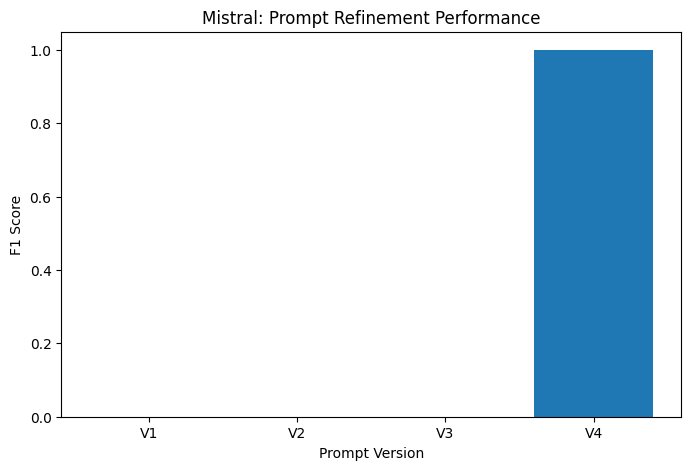

In [ ]:
import matplotlib.pyplot as plt

# Print the DataFrame being plotted to show the current F1 scores.
# These are currently all zero, which makes the bar chart appear empty.
print("Data for Mistral Snippet 1 Plot:")
print(mistral_all_results.shape)
print(mistral_all_results.columns.tolist())

# Use only Snippet 1 because it has positive ground-truth parameters
snippet1_plot = mistral_all_results[
    mistral_all_results["Snippet"] == "Privileged Spec 19.3.1"
]

print(snippet1_plot)

plt.figure(figsize=(8, 5))

plt.bar(
    snippet1_plot["Prompt"],
    snippet1_plot["F1"]
)

plt.xlabel("Prompt Version")
plt.ylabel("F1 Score")
plt.title("Mistral: Prompt Refinement Performance")
plt.ylim(0, 1.05)

plt.show()

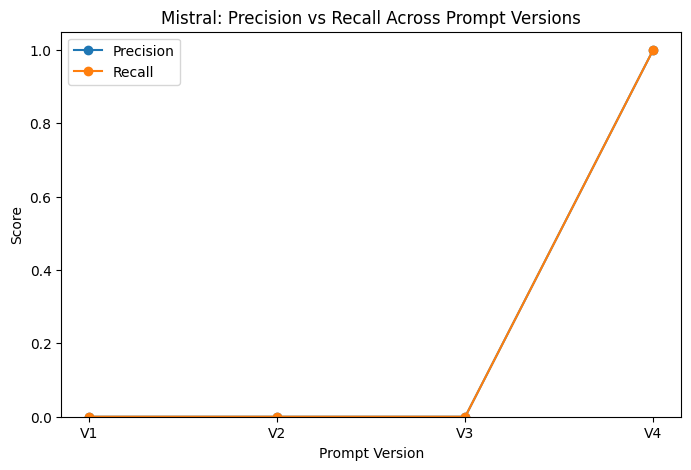

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    snippet1_plot["Prompt"],
    snippet1_plot["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    snippet1_plot["Prompt"],
    snippet1_plot["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Prompt Version")
plt.ylabel("Score")
plt.title("Mistral: Precision vs Recall Across Prompt Versions")
plt.ylim(0, 1.05)
plt.legend()

plt.show()

In [ ]:
evaluation = evaluate_extraction(
    all_prompt_results["V4"]["yaml"],
    ground_truth[1]
)
print(evaluation["predicted"])

{'cache_organization', 'cache_capacity', 'cache_block_size'}


## Part H — Gemini (Closed-Source) Experiments

| | Mistral 7B Instruct (open-source) | Gemini (closed-source) |
|---|---|---|
| Provider | OpenRouter (free tier, OpenAI-compatible API) | Google GenAI SDK |
| Parameters | ~7.3B | not disclosed by Google |
| Native context length | 32,768 tokens ([OpenRouter model card](https://openrouter.ai/mistralai/mistral-7b-instruct:free)) | not disclosed for this exact model string — confirm on the [Gemini API model list](https://ai.google.dev/gemini-api/docs/models) before submitting |
| License | Apache-2.0, open weights | proprietary, API-only |
| Sampling settings used here | `temperature=0`, `max_tokens=500-1000` | SDK defaults (temperature not explicitly pinned below — worth fixing for reproducibility) |


In [ ]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

print("Gemini key loaded:", bool(GEMINI_API_KEY))

Gemini key loaded: True


In [ ]:
!pip install -q google-genai

In [ ]:
from google import genai

gemini_client = genai.Client(
    api_key=GEMINI_API_KEY
)

print("Gemini client ready!")

Gemini client ready!


In [ ]:
def run_gemini_experiment(prompt_name, prompt_text, snippet_text):

    full_prompt = f"""
{prompt_text}

Specification:

{snippet_text}
"""

    answer = None
    for attempt in range(4):
        try:
            response = gemini_client.models.generate_content(
                model="gemini-3.5-flash-lite",
                contents=full_prompt
            )
            answer = response.text
            if answer: # Exit loop if a non-empty response is received
                break
        except Exception as e:
            print(f"Gemini API error (attempt {attempt+1}): {e}")
            time.sleep(3) # Wait before retrying

    if not answer:
        print(f"Failed to get response for {prompt_name} after multiple retries.")
        return {
            "prompt": prompt_name,
            "raw_response": None,
            "yaml": None,
            "yaml_valid": False
        }

    try:
        parsed_yaml = parse_yaml_response(answer)
        yaml_valid = True
    except Exception as e:
        parsed_yaml = None
        yaml_valid = False
        print(f"{prompt_name} YAML error:", e)

    return {
        "prompt": prompt_name,
        "raw_response": answer,
        "yaml": parsed_yaml,
        "yaml_valid": yaml_valid
    }

print("Gemini experiment function updated!")

Gemini experiment function updated!


In [ ]:
test_gemini = run_gemini_experiment(
    "V4",
    prompts["V4"],
    dataset[0]["text"]
)

print(test_gemini["raw_response"])

architectural_parameters:
  - name: cache capacity
    description: The storage capacity of a cache.
    type: implementation-defined
    constraints: null
    evidence: The capacity and organization of a cache and the size of a cache block are both implementation-specific
  - name: cache organization
    description: The structural organization of a cache.
    type: implementation-defined
    constraints: null
    evidence: The capacity and organization of a cache and the size of a cache block are both implementation-specific
  - name: cache block size
    description: The size of a cache block, representing a contiguous, naturally aligned power-of-two range of memory locations.
    type: implementation-defined
    constraints: Must be uniform throughout the system in the initial set of CMO extensions.
    evidence: The capacity and organization of a cache and the size of a cache block are both implementation-specific


In [ ]:
gemini_results = []

for prompt_name in ["V1", "V2", "V3", "V4"]:
    print("=" * 60)
    print(f"Gemini - Snippet 1 - {prompt_name}")
    print("=" * 60)

    try:
        result = run_gemini_experiment(
            prompt_name,
            prompts[prompt_name],
            dataset[0]["text"]
        )

        evaluation = evaluate_extraction(
            result["yaml"],
            ground_truth[1] # For Snippet 1
        )

        gemini_results.append({
            "Model": "Gemini",
            "Snippet": 1,
            "Prompt": prompt_name,
            "Precision": evaluation["precision"],
            "Recall": evaluation["recall"],
            "F1": evaluation["f1"],
            "Missing": len(evaluation["missing"]),
            "Hallucinations": len(evaluation["hallucinated"]),
            "Schema_Compliant": schema_compliant(result["yaml"])
        })

        print("Predicted:", evaluation["predicted"])
        print("Hallucinations:", evaluation["hallucinated"])

    except Exception as e:
        print("ERROR:", e)
        print("Skipping this prompt.")

gemini_results_df = pd.DataFrame(gemini_results)

gemini_results_df

Gemini - Snippet 1 - V1
Predicted: set()
Hallucinations: set()
Gemini - Snippet 1 - V2
Predicted: set()
Hallucinations: set()
Gemini - Snippet 1 - V3
Predicted: {'cache_block_size'}
Hallucinations: set()
Gemini - Snippet 1 - V4
Predicted: {'cache_organization', 'cache_capacity', 'cache_block_size'}
Hallucinations: set()


,Model,Snippet,Prompt,Precision,Recall,F1,Missing,Hallucinations,Schema_Compliant
0,Gemini,1,V1,0.0,0.000,0.0,3,0,False
1,Gemini,1,V2,0.0,0.000,0.0,3,0,False
2,Gemini,1,V3,1.0,0.333,0.5,2,0,True
3,Gemini,1,V4,1.0,1.000,1.0,0,0,True


In [ ]:
gemini_results_df.to_csv(
    "experiment_results/gemini_results.csv",
    index=False
)

print("Gemini results saved.")

Gemini results saved.


In [ ]:
snippet2_gemini_results = []

for prompt_name in ["V1", "V2", "V3", "V4"]:

    print("\n" + "=" * 60)
    print(f"Gemini - Snippet 2 - {prompt_name}")
    print("=" * 60)

    try:

        result = run_gemini_experiment(
            prompt_name,
            prompts[prompt_name],
            dataset[1]["text"]
        )

        evaluation = evaluate_extraction(
            result["yaml"],
            ground_truth[2]
        )

        snippet2_gemini_results.append({
            "Model": "Gemini",
            "Snippet": 2,
            "Prompt": prompt_name,
            "Precision": evaluation["precision"],
            "Recall": evaluation["recall"],
            "F1": evaluation["f1"],
            "Missing": len(evaluation["missing"]),
            "Hallucinations": len(evaluation["hallucinated"]),
            "Schema_Compliant": schema_compliant(result["yaml"])
        })

        print("Predicted:", evaluation["predicted"])
        print("Hallucinations:", evaluation["hallucinated"])

    except Exception as e:

        print("ERROR:", e)
        print("Skipping this prompt.")


Gemini - Snippet 2 - V1
Predicted: set()
Hallucinations: set()

Gemini - Snippet 2 - V2
Predicted: set()
Hallucinations: set()

Gemini - Snippet 2 - V3
Predicted: set()
Hallucinations: set()

Gemini - Snippet 2 - V4
Predicted: set()
Hallucinations: set()


In [ ]:
print(snippet2_gemini_results)

[{'Model': 'Gemini', 'Snippet': 2, 'Prompt': 'V1', 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Missing': 0, 'Hallucinations': 0, 'Schema_Compliant': False}, {'Model': 'Gemini', 'Snippet': 2, 'Prompt': 'V2', 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Missing': 0, 'Hallucinations': 0, 'Schema_Compliant': False}, {'Model': 'Gemini', 'Snippet': 2, 'Prompt': 'V3', 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Missing': 0, 'Hallucinations': 0, 'Schema_Compliant': True}, {'Model': 'Gemini', 'Snippet': 2, 'Prompt': 'V4', 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Missing': 0, 'Hallucinations': 0, 'Schema_Compliant': True}]


In [ ]:
# Combine Snippet 1 and Snippet 2 Gemini results

gemini_snippet2_df = pd.DataFrame(snippet2_gemini_results)

gemini_complete_df = pd.concat(
    [
        pd.DataFrame(gemini_results),
        gemini_snippet2_df
    ],
    ignore_index=True
)

gemini_complete_df

,Model,Snippet,Prompt,Precision,Recall,F1,Missing,Hallucinations,Schema_Compliant
0,Gemini,1,V1,0.0,0.000,0.0,3,0,False
1,Gemini,1,V2,0.0,0.000,0.0,3,0,False
2,Gemini,1,V3,1.0,0.333,0.5,2,0,True
3,Gemini,1,V4,1.0,1.000,1.0,0,0,True
4,Gemini,2,V1,1.0,1.000,1.0,0,0,False
5,Gemini,2,V2,1.0,1.000,1.0,0,0,False
6,Gemini,2,V3,1.0,1.000,1.0,0,0,True
7,Gemini,2,V4,1.0,1.000,1.0,0,0,True


In [ ]:
gemini_complete_df.to_csv(
    "experiment_results/gemini_complete_results.csv",
    index=False
)

print("Gemini results saved.")

Gemini results saved.


## Part I — Combining Results & Evaluation Metrics

For each (model, prompt version, snippet) run, predicted parameter names are compared
against the ground truth set:

- **Precision** = correct / predicted — of what the model extracted, how much was right.
- **Recall** = correct / ground_truth — of what should've been found, how much was found.
- **F1** = harmonic mean of precision and recall.
- **Missing** = ground_truth - predicted.
- **Hallucinations** = predicted - ground_truth.
- **Schema_Compliant** = whether the output matches the required
  `name/description/type/constraints` structure.

*(Memory trick: Precision = **don't cry wolf** — low precision means false alarms.
Recall = **recall it all** — low recall means you forgot things. A model can be
perfectly precise and still useless if recall is low, and vice versa — F1 punishes
either extreme.)*

In [ ]:
all_results = pd.concat(
    [
        mistral_all_results,
        gemini_complete_df
    ],
    ignore_index=True
)

all_results

,Model,Prompt,Precision,Recall,F1,Missing,Hallucinations,Predicted,Schema_Compliant,Snippet
0,Mistral-7B-Instruct,V1,0.0,0.000,0.0,3.0,0,0.0,False,Privileged Spec 19.3.1
1,Mistral-7B-Instruct,V2,0.0,0.000,0.0,3.0,0,0.0,False,Privileged Spec 19.3.1
2,Mistral-7B-Instruct,V3,0.0,0.000,0.0,3.0,0,0.0,True,Privileged Spec 19.3.1
3,Mistral-7B-Instruct,V4,1.0,1.000,1.0,0.0,0,3.0,True,Privileged Spec 19.3.1
4,Mistral-7B-Instruct,V1,1.0,1.000,1.0,NaN,0,0.0,NaN,Privileged Spec 2.1
5,Mistral-7B-Instruct,V2,1.0,1.000,1.0,NaN,0,0.0,NaN,Privileged Spec 2.1
6,Mistral-7B-Instruct,V3,1.0,1.000,1.0,NaN,0,0.0,NaN,Privileged Spec 2.1
7,Mistral-7B-Instruct,V4,1.0,1.000,1.0,NaN,0,0.0,NaN,Privileged Spec 2.1
8,Gemini,V1,0.0,0.000,0.0,3.0,0,NaN,False,1
9,Gemini,V2,0.0,0.000,0.0,3.0,0,NaN,False,1


In [ ]:
all_results.to_csv(
    "experiment_results/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved.")

Final model comparison saved.


In [ ]:
all_results

,Model,Prompt,Precision,Recall,F1,Missing,Hallucinations,Predicted,Schema_Compliant,Snippet
0,Mistral-7B-Instruct,V1,0.0,0.000,0.0,3.0,0,0.0,False,Privileged Spec 19.3.1
1,Mistral-7B-Instruct,V2,0.0,0.000,0.0,3.0,0,0.0,False,Privileged Spec 19.3.1
2,Mistral-7B-Instruct,V3,0.0,0.000,0.0,3.0,0,0.0,True,Privileged Spec 19.3.1
3,Mistral-7B-Instruct,V4,1.0,1.000,1.0,0.0,0,3.0,True,Privileged Spec 19.3.1
4,Mistral-7B-Instruct,V1,1.0,1.000,1.0,NaN,0,0.0,NaN,Privileged Spec 2.1
5,Mistral-7B-Instruct,V2,1.0,1.000,1.0,NaN,0,0.0,NaN,Privileged Spec 2.1
6,Mistral-7B-Instruct,V3,1.0,1.000,1.0,NaN,0,0.0,NaN,Privileged Spec 2.1
7,Mistral-7B-Instruct,V4,1.0,1.000,1.0,NaN,0,0.0,NaN,Privileged Spec 2.1
8,Gemini,V1,0.0,0.000,0.0,3.0,0,NaN,False,1
9,Gemini,V2,0.0,0.000,0.0,3.0,0,NaN,False,1


In [ ]:
print(ground_truth)

{1: {'cache_organization', 'cache_capacity', 'cache_block_size'}, 2: set()}


In [ ]:
def normalize_parameter_name(name):
    name = str(name).strip().lower()

    # Normalize spaces and hyphens
    name = name.replace("-", "_")
    name = name.replace(" ", "_")

    # Common Gemini/Mistral variations
    aliases = {
        "cache_capacity": "cache_capacity",
        "cache_organization": "cache_organization",
        "cache_block_size": "cache_block_size",
        "size_of_cache_block": "cache_block_size",
    }

    return aliases.get(name, name)


def extract_parameter_names(output):

    predicted_raw = set()

    if not isinstance(output, dict):
        return set()

    # ------------------------------------------------
    # Format 1:
    # architectural_parameters:
    #   - name: ...
    # ------------------------------------------------

    if "architectural_parameters" in output:

        parameters = output["architectural_parameters"]

        if isinstance(parameters, list):

            for parameter in parameters:

                if isinstance(parameter, dict):
                    if "name" in parameter:
                        predicted_raw.add(parameter["name"])

        elif isinstance(parameters, dict):

            predicted_raw.update(parameters.keys())

    # ------------------------------------------------
    # Format 2:
    # caches:
    #   cache_block_size:
    #   cache_capacity:
    # ------------------------------------------------

    if "caches" in output:

        caches = output["caches"]

        if isinstance(caches, dict):
            predicted_raw.update(caches.keys())

    # ------------------------------------------------
    # Format 3:
    # implementation_defined_parameters:
    #   - name: ...
    # ------------------------------------------------

    if "implementation_defined_parameters" in output:

        parameters = output["implementation_defined_parameters"]

        if isinstance(parameters, list):

            for parameter in parameters:

                if isinstance(parameter, dict):
                    if "name" in parameter:
                        predicted_raw.add(parameter["name"])

    # ------------------------------------------------
    # Format 4:
    # implementation-specific:
    #   - capacity
    # ------------------------------------------------

    if "implementation-specific" in output:

        values = output["implementation-specific"]

        if isinstance(values, list):
            predicted_raw.update(values)

    # Normalize everything
    predicted = {
        normalize_parameter_name(name)
        for name in predicted_raw
    }

    return predicted

def evaluate_extraction(output, ground_truth):

    predicted = extract_parameter_names(output)

    ground = {
        normalize_parameter_name(name)
        for name in ground_truth
    }

    correct = predicted.intersection(ground)
    missing = ground - predicted
    hallucinated = predicted - ground

    # Normal case: parameters are expected
    if len(ground) > 0:

        precision = (
            len(correct) / len(predicted)
            if len(predicted) > 0
            else 0
        )

        recall = len(correct) / len(ground)

        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall > 0
            else 0
        )

    # Negative case: NO parameters are expected
    else:

        if len(predicted) == 0:
            precision = 1.0
            recall = 1.0
            f1 = 1.0
        else:
            precision = 0.0
            recall = 0.0
            f1 = 0.0

    return {
        "predicted": predicted,
        "correct": correct,
        "missing": missing,
        "hallucinated": hallucinated,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3)
    }

In [ ]:
all_results["Snippet_ID"] = all_results["Snippet"].astype(str).apply(
    lambda x: "Snippet 1" if "19.3.1" in x or x == "1"
    else "Snippet 2" if "2.1" in x or x == "2"
    else x
)

all_results[["Model", "Prompt", "Snippet", "Snippet_ID"]]

,Model,Prompt,Snippet,Snippet_ID
0,Mistral-7B-Instruct,V1,Privileged Spec 19.3.1,Snippet 1
1,Mistral-7B-Instruct,V2,Privileged Spec 19.3.1,Snippet 1
2,Mistral-7B-Instruct,V3,Privileged Spec 19.3.1,Snippet 1
3,Mistral-7B-Instruct,V4,Privileged Spec 19.3.1,Snippet 1
4,Mistral-7B-Instruct,V1,Privileged Spec 2.1,Snippet 2
5,Mistral-7B-Instruct,V2,Privileged Spec 2.1,Snippet 2
6,Mistral-7B-Instruct,V3,Privileged Spec 2.1,Snippet 2
7,Mistral-7B-Instruct,V4,Privileged Spec 2.1,Snippet 2
8,Gemini,V1,1,Snippet 1
9,Gemini,V2,1,Snippet 1


## Part J — Visualization

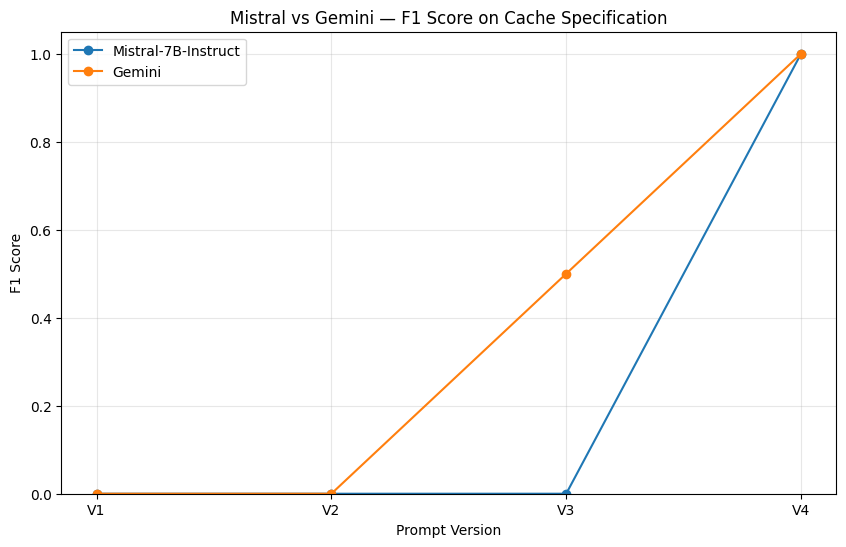

In [ ]:
import matplotlib.pyplot as plt

plot_data = all_results[
    all_results["Snippet_ID"] == "Snippet 1"
].copy()

plt.figure(figsize=(10, 6))

for model in plot_data["Model"].unique():

    model_data = plot_data[
        plot_data["Model"] == model
    ].sort_values("Prompt")

    plt.plot(
        model_data["Prompt"],
        model_data["F1"],
        marker="o",
        label=model
    )

plt.xlabel("Prompt Version")
plt.ylabel("F1 Score")
plt.title("Mistral vs Gemini — F1 Score on Cache Specification")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

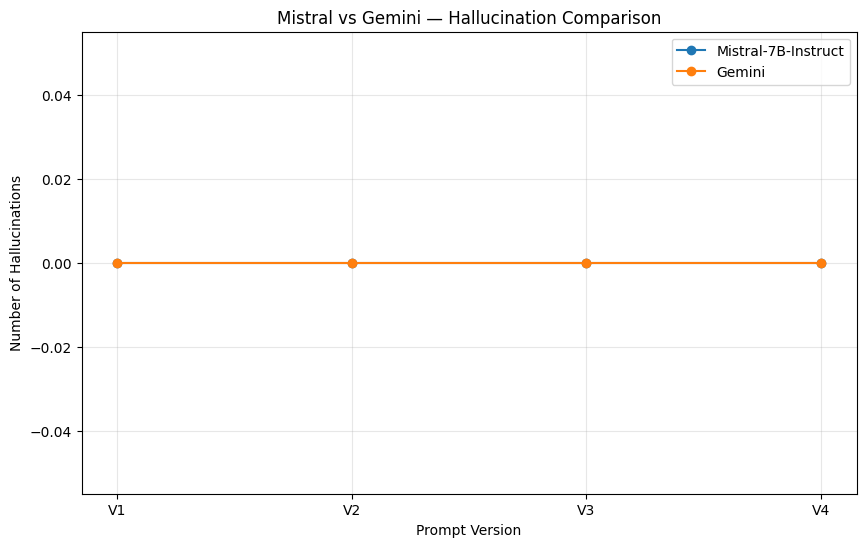

In [ ]:
plot_data = all_results[
    all_results["Snippet_ID"] == "Snippet 2"
].copy()

plt.figure(figsize=(10, 6))

for model in plot_data["Model"].unique():

    model_data = plot_data[
        plot_data["Model"] == model
    ].sort_values("Prompt")

    plt.plot(
        model_data["Prompt"],
        model_data["Hallucinations"],
        marker="o",
        label=model
    )

plt.xlabel("Prompt Version")
plt.ylabel("Number of Hallucinations")
plt.title("Mistral vs Gemini — Hallucination Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

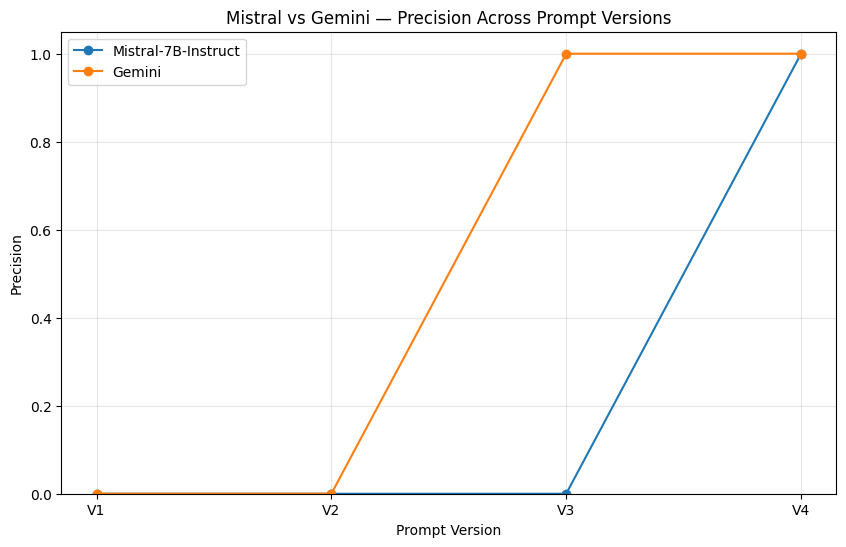

In [ ]:
import matplotlib.pyplot as plt

plot_data = all_results[
    all_results["Snippet_ID"] == "Snippet 1"
].copy()

plt.figure(figsize=(10, 6))

for model in plot_data["Model"].unique():

    model_data = plot_data[
        plot_data["Model"] == model
    ].sort_values("Prompt")

    plt.plot(
        model_data["Prompt"],
        model_data["Precision"],
        marker="o",
        label=model
    )

plt.xlabel("Prompt Version")
plt.ylabel("Precision")
plt.title("Mistral vs Gemini — Precision Across Prompt Versions")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

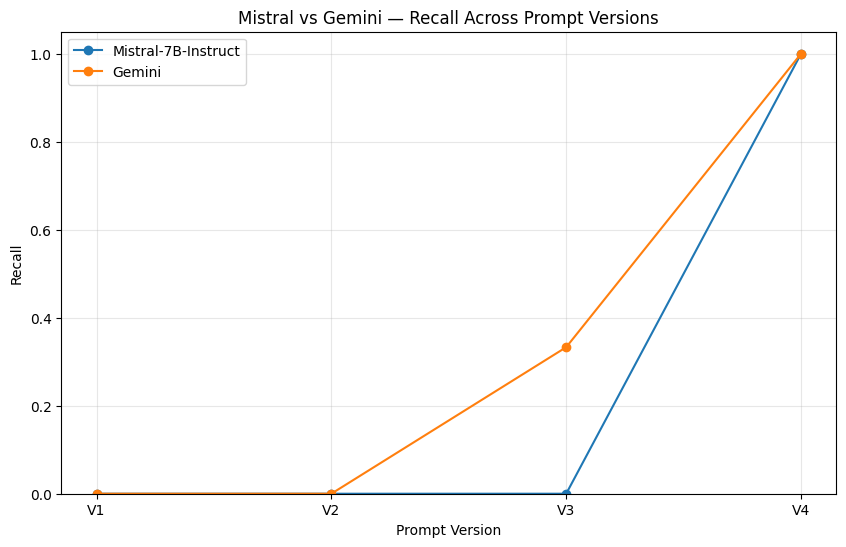

In [ ]:
import matplotlib.pyplot as plt

plot_data = all_results[
    all_results["Snippet_ID"] == "Snippet 1"
].copy()

plt.figure(figsize=(10, 6))

for model in plot_data["Model"].unique():

    model_data = plot_data[
        plot_data["Model"] == model
    ].sort_values("Prompt")

    plt.plot(
        model_data["Prompt"],
        model_data["Recall"],
        marker="o",
        label=model
    )

plt.xlabel("Prompt Version")
plt.ylabel("Recall")
plt.title("Mistral vs Gemini — Recall Across Prompt Versions")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(all_results[all_results["Snippet"].astype(str).str.contains("2|2.1")][["Model","Prompt","Precision","Recall","F1"]])

                  Model Prompt  Precision  Recall   F1
4   Mistral-7B-Instruct     V1        1.0     1.0  1.0
5   Mistral-7B-Instruct     V2        1.0     1.0  1.0
6   Mistral-7B-Instruct     V3        1.0     1.0  1.0
7   Mistral-7B-Instruct     V4        1.0     1.0  1.0
12               Gemini     V1        1.0     1.0  1.0
13               Gemini     V2        1.0     1.0  1.0
14               Gemini     V3        1.0     1.0  1.0
15               Gemini     V4        1.0     1.0  1.0


## Part K — Final Comparison

In [ ]:
# Final comparison for Snippet 1
final_comparison = all_results[
    all_results["Snippet_ID"] == "Snippet 1"
].copy()

final_comparison = final_comparison[
    [
        "Model",
        "Prompt",
        "Precision",
        "Recall",
        "F1",
        "Hallucinations"
    ]
].sort_values(["Model", "Prompt"])

display(final_comparison)

,Model,Prompt,Precision,Recall,F1,Hallucinations
8,Gemini,V1,0.0,0.000,0.0,0
9,Gemini,V2,0.0,0.000,0.0,0
10,Gemini,V3,1.0,0.333,0.5,0
11,Gemini,V4,1.0,1.000,1.0,0
0,Mistral-7B-Instruct,V1,0.0,0.000,0.0,0
1,Mistral-7B-Instruct,V2,0.0,0.000,0.0,0
2,Mistral-7B-Instruct,V3,0.0,0.000,0.0,0
3,Mistral-7B-Instruct,V4,1.0,1.000,1.0,0


In [ ]:
best_prompts = (
    final_comparison
    .sort_values("F1", ascending=False)
    .groupby("Model")
    .first()
    .reset_index()
)

display(best_prompts)

,Model,Prompt,Precision,Recall,F1,Hallucinations
0,Gemini,V4,1.0,1.0,1.0,0
1,Mistral-7B-Instruct,V4,1.0,1.0,1.0,0


In [ ]:
print("=" * 70)
print("MISTRAL V2 — FINAL OUTPUT")
print("=" * 70)

print(all_prompt_results["V2"]["raw_response"])

print("\n" + "=" * 70)
print("GEMINI V4 — FINAL OUTPUT")
print("=" * 70)

print(test_gemini["raw_response"])

MISTRAL V2 — FINAL OUTPUT
```yaml
parameters:
  - cache_capacity:
      description: Capacity of a cache
      attribute: implementation-specific
  - cache_organization:
      description: Organization of a cache
      attribute: implementation-specific
  - cache_block_size:
      description: Size of a cache block
      attribute: implementation-specific
```

GEMINI V4 — FINAL OUTPUT
architectural_parameters:
  - name: cache capacity
    description: The storage capacity of a cache.
    type: implementation-defined
    constraints: null
    evidence: The capacity and organization of a cache and the size of a cache block are both implementation-specific
  - name: cache organization
    description: The structural organization of a cache.
    type: implementation-defined
    constraints: null
    evidence: The capacity and organization of a cache and the size of a cache block are both implementation-specific
  - name: cache block size
    description: The size of a cache block, represen

## Part L — Final YAML Results

Deliverable 3. Both snippets are included explicitly — Snippet 2 correctly resolves to
an empty parameter list rather than being left out, since an empty result here is a
correct finding, not a gap in the work.

In [ ]:
import yaml

final_yaml = {
    "snippet_1": {
        "source": "Privileged Spec 19.3.1",
        "architectural_parameters": [
            {
                "name": "cache_capacity",
                "description": "Capacity of a cache in the system.",
                "type": "integer",
                "constraints": "Implementation-specific.",
                "evidence": "The capacity and organization of a cache and the size of a cache block are both implementation-specific"
            },
            {
                "name": "cache_organization",
                "description": "Organization and structure of a cache.",
                "type": "implementation-defined",
                "constraints": "Implementation-specific.",
                "evidence": "The capacity and organization of a cache and the size of a cache block are both implementation-specific"
            },
            {
                "name": "cache_block_size",
                "description": "Size of a cache block in memory locations.",
                "type": "integer",
                "constraints": "Must represent a contiguous, naturally aligned power-of-two (NAPOT) range of memory locations. Shall be uniform throughout the system in the initial set of CMO extensions.",
                "evidence": "In the initial set of CMO extensions, the size of a cache block shall be uniform throughout the system."
            }
        ]
    },
    "snippet_2": {
        "source": "Privileged Spec 2.1",
        "architectural_parameters": []
    }
}

print(yaml.dump(final_yaml, sort_keys=False))


snippet_1:
  source: Privileged Spec 19.3.1
  architectural_parameters:
  - name: cache_capacity
    description: Capacity of a cache in the system.
    type: integer
    constraints: Implementation-specific.
    evidence: The capacity and organization of a cache and the size of a cache block
      are both implementation-specific
  - name: cache_organization
    description: Organization and structure of a cache.
    type: implementation-defined
    constraints: Implementation-specific.
    evidence: The capacity and organization of a cache and the size of a cache block
      are both implementation-specific
  - name: cache_block_size
    description: Size of a cache block in memory locations.
    type: integer
    constraints: Must represent a contiguous, naturally aligned power-of-two (NAPOT)
      range of memory locations. Shall be uniform throughout the system in the initial
      set of CMO extensions.
    evidence: In the initial set of CMO extensions, the size of a cache block

In [ ]:
with open("final_results.yaml", "w") as f:
    yaml.dump(final_yaml, f, sort_keys=False)

print("Saved as final_results.yaml")

Saved as final_results.yaml


In [ ]:
from google.colab import files
files.download("experiment_results/final_model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>